<a href="https://colab.research.google.com/github/jeremie-star/NLP-and-Language-Technologies/blob/main/person2_models_3_4_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GBV Tweet Classification — Person 2
## Models 3 (TextCNN) & 4 (BiLSTM)

Consumes Person 1's canonical split + low-resource protocol, trains two
neural sequential models across n = 250 / 500 / 1000 / 2500 / full
(3 seeds at small sizes), and writes results in Person 1's schema so the
five-model comparison combines.

**Before running:** Runtime → Change runtime type → **T4 GPU**.
When prompted, upload Person 1's four files:
`train.csv`, `val.csv`, `test.csv`, `low_resource_protocol.json`.
Then Runtime → Run all.

### What this notebook fixes vs the previous version
- Removed the `os.remove` crash cell
- Removed the duplicate setup cell
- Fixed BiLSTM: padding-aware with `pack_padded_sequence`
- `train_one` now records loss + val-F1 history for learning curves
- Added class-weight ablation experiment
- Added learning-curve plots (saved to figures/)
- Full-data predictions stored from sweep (no wasted retraining)


In [ ]:
# ============================================================================
# GBV Tweet Classification — Person 2: Models 3 (TextCNN) & 4 (BiLSTM)
# FIXED VERSION — all reviewer issues addressed
# ============================================================================


In [ ]:
# ------------------------------------------------------------------ 0. setup
import os, re, json, random, hashlib, math, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                             precision_recall_fscore_support, confusion_matrix,
                             classification_report)

warnings.filterwarnings("ignore", category=UserWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type != "cuda":
    print("  WARNING: no GPU detected. Set Runtime -> Change runtime type -> T4 GPU.")

# ── inherited constants (Person 1's handoff) ─────────────────────────────────
LABELS = ["sexual_violence", "physical_violence", "emotional_violence",
          "economic_violence", "harmful_traditional_practice"]
SHORT  = {"sexual_violence": "sexual", "physical_violence": "physical",
          "emotional_violence": "emotional", "economic_violence": "economic",
          "harmful_traditional_practice": "harmful trad."}
LAB2ID = {l: i for i, l in enumerate(LABELS)}
MAX_LEN  = 61        # Person 1 p99 word-length budget (Section 3)
TEXT_COL = "text"   # pre-cleaned column; stated in report methodology

# shared plotting palette (Person 1's system)
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e8e7e3"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SERIES = [BLUE, ORANGE, AQUA]
SEQ = ["#eef5fd","#cde2fb","#9ec5f4","#6da7ec","#3987e5",
       "#2a78d6","#256abf","#1c5cab","#184f95","#0d366b"]
CMAP_SEQ = LinearSegmentedColormap.from_list("seq_blue", SEQ)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "savefig.dpi": 150,
    "savefig.bbox": "tight", "figure.dpi": 110,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
    "legend.frameon": False, "font.size": 10,
    "axes.titlesize": 11.5, "axes.titleweight": "semibold",
    "axes.titlepad": 12, "xtick.major.size": 0, "ytick.major.size": 0,
})

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

print("setup done")


device: cuda
setup done


In [ ]:
# --------------------------------------------------------- 1. locate files
# FIX: os.remove crash cell deleted; duplicate setup cell deleted.
# Upload all four files when prompted, or set USE_DRIVE_PATHS=True.

USE_DRIVE_PATHS = False
DRIVE = Path("/content/drive/MyDrive/gbv_tweet_project/data/splits")

EXPECTED_MD5 = {
    "train.csv": "7eb4634bdd6ee53babecffcbe2013354",
    "val.csv":   "849d1a4e1d7789f8be43933071b02374",
    "test.csv":  "1af88d754c02f35ca339ba992444ed56",
}
NEEDED = ["train.csv", "val.csv", "test.csv", "low_resource_protocol.json"]

def md5sum(path, buf=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as fh:
        for b in iter(lambda: fh.read(buf), b""): h.update(b)
    return h.hexdigest()

IN_COLAB = "google.colab" in __import__("sys").modules
FILES = {}

if USE_DRIVE_PATHS:
    from google.colab import drive
    drive.mount("/content/drive")
    for n in NEEDED:
        FILES[n] = DRIVE / n
elif IN_COLAB:
    from google.colab import files as colab_files
    print("Upload Person 1s four files: train.csv, val.csv, test.csv, "
          "low_resource_protocol.json")
    up = colab_files.upload()
    for n in NEEDED:
        found_key = None
        for k in up:
            if k == n:
                found_key = k; break
            base_n, ext_n = os.path.splitext(n)
            base_k, ext_k = os.path.splitext(k)
            if (ext_k == ext_n and base_k.startswith(base_n)
                    and re.fullmatch(base_n + r" \(\d+\)", base_k)):
                found_key = k; break
        assert found_key, f"missing {n} in upload"
        FILES[n] = Path(found_key)
else:
    for n in NEEDED:
        FILES[n] = Path(n)

print("\nchecksum verification:")
for n in ["train.csv", "val.csv", "test.csv"]:
    got = md5sum(FILES[n])
    ok  = got == EXPECTED_MD5[n]
    print(f"  {n:10s} {got}  {'MATCH' if ok else 'MISMATCH!'}")
    assert ok, f"{n} does not match Person 1s split — do not proceed."
print("  all splits verified\n")

OUT = Path("/content/gbv_p2" if IN_COLAB else "./gbv_p2")
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "results").mkdir(parents=True, exist_ok=True)


Upload Person 1s four files: train.csv, val.csv, test.csv, low_resource_protocol.json


Saving low_resource_protocol.json to low_resource_protocol.json
Saving val.csv to val.csv
Saving test.csv to test.csv
Saving train.csv to train.csv

checksum verification:
  train.csv  7eb4634bdd6ee53babecffcbe2013354  MATCH
  val.csv    849d1a4e1d7789f8be43933071b02374  MATCH
  test.csv   1af88d754c02f35ca339ba992444ed56  MATCH
  all splits verified



In [ ]:
# --------------------------------------------------------- 2. load data
train_df = pd.read_csv(FILES["train.csv"])
val_df   = pd.read_csv(FILES["val.csv"])
test_df  = pd.read_csv(FILES["test.csv"])
protocol = json.load(open(FILES["low_resource_protocol.json"]))

for d in (train_df, val_df, test_df):
    d["label"] = d["label"].str.strip().str.lower()
    d["y"]     = d["label"].map(LAB2ID)

print("train", len(train_df), "| val", len(val_df), "| test", len(test_df))
print("protocol sizes:", protocol["sizes"], "seeds:", protocol["seeds"])
SIZES = protocol["sizes"]   # [250, 500, 1000, 2500, 'full']
SEEDS = protocol["seeds"]   # [42, 1337, 2024]


train 27764 | val 5941 | test 5945
protocol sizes: [250, 500, 1000, 2500, 'full'] seeds: [42, 1337, 2024]


In [ ]:
# ----------------------------------------- 3. tokeniser & vocabulary
WORD_RE = re.compile(r"[a-z']+")

def tokenize(s):
    return WORD_RE.findall(str(s).lower())

PAD, UNK = "<pad>", "<unk>"

def build_vocab(texts, max_size=20000, min_freq=1):
    # 20k cap: keeps token-OOV ~2% (Person 1 Section 4 OOV table)
    c = Counter(w for t in texts for w in tokenize(t))
    itos = [PAD, UNK] + [w for w, f in c.most_common(max_size)
                         if f >= min_freq]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos

def encode(s, stoi):
    ids = [stoi.get(w, 1) for w in tokenize(s)][:MAX_LEN]
    ids += [0] * (MAX_LEN - len(ids))   # pad to MAX_LEN
    return ids

class TweetDS(Dataset):
    def __init__(self, df, stoi):
        self.X = [encode(s, stoi) for s in df[TEXT_COL].values]
        self.y = df["y"].values
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i])


In [ ]:
# ------------------------------------------------------------ 4. models

class TextCNN(nn.Module):
    """Model 3 — convolutional filters (kernels 2/3/4) capture LOCAL
    n-gram patterns, max-pooled over time.
    Inductive bias: position-invariant local features; no recurrence."""
    def __init__(self, vocab, emb=100, n_filters=100,
                 kernels=(2,3,4), n_classes=5, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab, emb, padding_idx=0)
        self.convs = nn.ModuleList(
            [nn.Conv1d(emb, n_filters, k, padding=k-1) for k in kernels])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(kernels), n_classes)

    def forward(self, x):
        e = self.embedding(x).transpose(1, 2)        # (B, emb, T)
        feats = [F.relu(c(e)).max(dim=2).values for c in self.convs]
        return self.fc(self.dropout(torch.cat(feats, dim=1)))


class BiLSTM(nn.Module):
    """Model 4 — bidirectional LSTM reads sequence in both directions,
    capturing ORDER and sequential dependency.
    FIX: uses pack_padded_sequence so padding tokens do not contaminate
    the forward hidden state (reviewer bug B7)."""
    def __init__(self, vocab, emb=100, hidden=128,
                 n_classes=5, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hidden, batch_first=True,
                            bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, n_classes)

    def forward(self, x):
        e = self.embedding(x)
        lengths = (x != 0).sum(dim=1).cpu().clamp(min=1)
        packed = nn.utils.rnn.pack_padded_sequence(
            e, lengths, batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)               # h: (2, B, hidden)
        h = torch.cat([h[0], h[1]], dim=1)          # (B, 2*hidden)
        return self.fc(self.dropout(h))

MODELS = {"M3 TextCNN": TextCNN, "M4 BiLSTM": BiLSTM}
print("models defined:", list(MODELS.keys()))


models defined: ['M3 TextCNN', 'M4 BiLSTM']


In [ ]:
# ---------------------------------------------------------- 5. training harness
# FIX: train_one now returns history (loss + val-F1 per epoch)
# so learning curves can be plotted without retraining.

def class_weights(sub_df):
    counts = (sub_df["y"].value_counts()
                         .reindex(range(len(LABELS))).fillna(0).values)
    w = 1.0 / np.sqrt(counts + 1.0)
    w = w / w.sum() * len(LABELS)
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

@torch.no_grad()
def predict(model, loader):
    model.eval()
    out = []
    for xb, _ in loader:
        out.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(out)

def train_one(ModelCls, sub_df, stoi, seed, use_weights=True,
              epochs=40, patience=6, bs=64, lr=1e-3, verbose=False):
    set_seed(seed)
    tr_loader = DataLoader(TweetDS(sub_df, stoi), bs, shuffle=True)
    va_loader = DataLoader(TweetDS(val_df,  stoi), 256, shuffle=False)

    model = ModelCls(len(stoi)).to(DEVICE)
    crit  = nn.CrossEntropyLoss(
        weight=class_weights(sub_df) if use_weights else None)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)

    best_f1, best_state, wait = -1.0, None, 0
    history = {"train_loss": [], "val_macro_f1": []}

    for ep in range(epochs):
        model.train()
        ep_loss = 0.0
        for xb, yb in tr_loader:
            opt.zero_grad()
            loss = crit(model(xb.to(DEVICE)), yb.to(DEVICE))
            loss.backward(); opt.step()
            ep_loss += loss.item()
        history["train_loss"].append(ep_loss / len(tr_loader))

        vf1 = f1_score(val_df["y"].values, predict(model, va_loader),
                       average="macro", labels=list(range(len(LABELS))),
                       zero_division=0)
        history["val_macro_f1"].append(vf1)

        if vf1 > best_f1:
            best_f1   = vf1
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
        if verbose:
            print(f"    ep{ep:02d} loss {ep_loss/len(tr_loader):.4f} "
                  f"val_macroF1 {vf1:.4f}")

    model.load_state_dict(best_state)
    return model, best_f1, history   # <-- history now returned

def evaluate_split(model, df, stoi):
    loader = DataLoader(TweetDS(df, stoi), 256, shuffle=False)
    pred   = predict(model, loader)
    y      = df["y"].values
    _, _, f, _ = precision_recall_fscore_support(
        y, pred, labels=list(range(len(LABELS))), zero_division=0)
    row = {
        "macro_f1":     f1_score(y, pred, average="macro",
                                 labels=list(range(len(LABELS))),
                                 zero_division=0),
        "balanced_acc": balanced_accuracy_score(y, pred),
        "weighted_f1":  f1_score(y, pred, average="weighted",
                                 labels=list(range(len(LABELS))),
                                 zero_division=0),
        "accuracy":     accuracy_score(y, pred),
    }
    for i, lab in enumerate(LABELS):
        row[f"f1_{SHORT[lab]}"] = f[i]
    return row, pred

def subset_for(size, seed):
    if size == "full":
        return train_df
    ids = set(protocol["subsets"][f"n{size}_seed{seed}"])
    return train_df[train_df["Tweet_ID"].isin(ids)].reset_index(drop=True)

print("training harness ready")


training harness ready


In [ ]:
# --------------------------------------- 6. low-resource sweep
# FIX: model, vbest, history = train_one(...)  (three return values now)
# Predictions stored in PREDS dict so cell 9 skips redundant retraining.
RESULTS = []
PREDS   = {}   # keyed by (mname, size, seed) for the full-data runs
t0 = time.time()

for mname, ModelCls in MODELS.items():
    for size in SIZES:
        seeds = SEEDS if size != "full" else [SEEDS[0]]
        for seed in seeds:
            sub  = subset_for(size, seed)
            stoi, _ = build_vocab(sub[TEXT_COL].values)
            model, vbest, hist = train_one(
                ModelCls, sub, stoi, seed, use_weights=True)
            test_row, pred = evaluate_split(model, test_df, stoi)
            RESULTS.append({
                "model": mname, "config": f"n={size}",
                "split": "test",
                "train_size": len(train_df) if size == "full" else size,
                "size_tag": str(size), "seed": seed,
                "vocab": len(stoi), "val_macro_f1": vbest,
                "note": "class-weighted; early-stop on val macroF1",
                **test_row,
            })
            if size == "full":
                PREDS[(mname, size, seed)] = (pred, stoi, hist)
            print(f"{mname:12s} n={str(size):5s} seed={seed:<4d} "
                  f"val {vbest:.3f} | test macroF1 "
                  f"{test_row['macro_f1']:.3f} "
                  f"acc {test_row['accuracy']:.3f} | vocab {len(stoi)}")

res = pd.DataFrame(RESULTS)
res.to_csv(OUT / "results" / "results_models_3_4.csv", index=False)
print(f"\ndone in {(time.time()-t0)/60:.1f} min")


M3 TextCNN   n=250   seed=42   val 0.387 | test macroF1 0.389 acc 0.964 | vocab 2150
M3 TextCNN   n=250   seed=1337 val 0.427 | test macroF1 0.405 acc 0.969 | vocab 2131
M3 TextCNN   n=250   seed=2024 val 0.389 | test macroF1 0.390 acc 0.965 | vocab 1980
M3 TextCNN   n=500   seed=42   val 0.420 | test macroF1 0.419 acc 0.972 | vocab 3306
M3 TextCNN   n=500   seed=1337 val 0.542 | test macroF1 0.529 acc 0.978 | vocab 3211
M3 TextCNN   n=500   seed=2024 val 0.408 | test macroF1 0.404 acc 0.972 | vocab 3156
M3 TextCNN   n=1000  seed=42   val 0.740 | test macroF1 0.741 acc 0.988 | vocab 4959
M3 TextCNN   n=1000  seed=1337 val 0.755 | test macroF1 0.681 acc 0.987 | vocab 4927
M3 TextCNN   n=1000  seed=2024 val 0.832 | test macroF1 0.773 acc 0.990 | vocab 4921
M3 TextCNN   n=2500  seed=42   val 0.952 | test macroF1 0.958 acc 0.998 | vocab 8430
M3 TextCNN   n=2500  seed=1337 val 0.980 | test macroF1 0.979 acc 0.999 | vocab 8503
M3 TextCNN   n=2500  seed=2024 val 0.972 | test macroF1 0.965 acc

In [ ]:
# --------------------------------------- 7. aggregate mean +/- sd
agg = (res.groupby(["model", "train_size", "size_tag"])
          .agg(macro_f1_mean=("macro_f1","mean"),
               macro_f1_sd  =("macro_f1","std"),
               acc_mean     =("accuracy","mean"),
               f1_physical  =("f1_physical","mean"),
               f1_emotional =("f1_emotional","mean"))
          .reset_index()
          .sort_values(["model","train_size"]))
agg["macro_f1_sd"] = agg["macro_f1_sd"].fillna(0.0)
agg.to_csv(OUT / "results" / "aggregate_models_3_4.csv", index=False)

print("\n=== macro-F1 by training size (mean +/- sd) ===")
for m in MODELS:
    print(f"\n{m}")
    for _, r in agg[agg["model"]==m].iterrows():
        print(f"  n={r['size_tag']:5s}  "
              f"macroF1 {r['macro_f1_mean']:.3f} +/- {r['macro_f1_sd']:.3f}"
              f"   acc {r['acc_mean']:.3f}"
              f"   f1(phys) {r['f1_physical']:.3f}"
              f"   f1(emot) {r['f1_emotional']:.3f}")



=== macro-F1 by training size (mean +/- sd) ===

M3 TextCNN
  n=250    macroF1 0.395 +/- 0.009   acc 0.966   f1(phys) 0.974   f1(emot) 0.000
  n=500    macroF1 0.451 +/- 0.069   acc 0.974   f1(phys) 0.990   f1(emot) 0.201
  n=1000   macroF1 0.731 +/- 0.047   acc 0.988   f1(phys) 0.997   f1(emot) 0.882
  n=2500   macroF1 0.967 +/- 0.011   acc 0.998   f1(phys) 0.999   f1(emot) 0.990
  n=full   macroF1 0.992 +/- 0.000   acc 0.999   f1(phys) 0.998   f1(emot) 0.980

M4 BiLSTM
  n=250    macroF1 0.377 +/- 0.006   acc 0.950   f1(phys) 0.912   f1(emot) 0.000
  n=500    macroF1 0.405 +/- 0.020   acc 0.950   f1(phys) 0.910   f1(emot) 0.090
  n=1000   macroF1 0.507 +/- 0.069   acc 0.965   f1(phys) 0.957   f1(emot) 0.358
  n=2500   macroF1 0.813 +/- 0.082   acc 0.984   f1(phys) 0.982   f1(emot) 0.758
  n=full   macroF1 0.986 +/- 0.000   acc 0.999   f1(phys) 0.999   f1(emot) 0.995


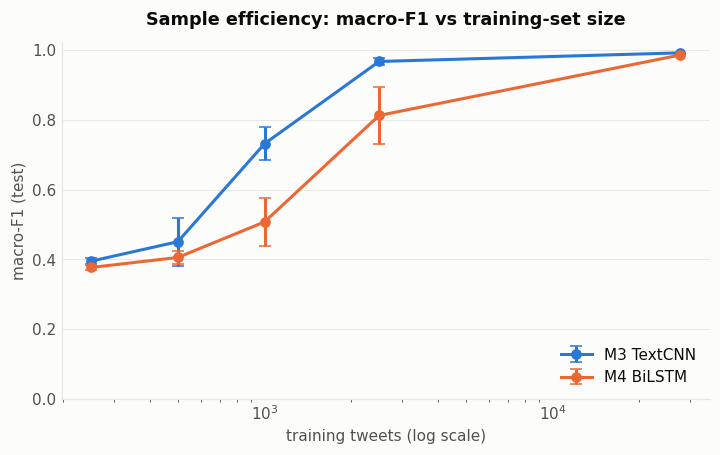

saved 10_efficiency_m3_m4.png


In [ ]:
# --------------------------------------- 8. sample-efficiency figure
fig, ax = plt.subplots(figsize=(7.6, 4.2))
for i, m in enumerate(MODELS):
    sub = agg[agg["model"]==m].sort_values("train_size")
    ax.errorbar(sub["train_size"], sub["macro_f1_mean"],
                yerr=sub["macro_f1_sd"],
                marker="o", ms=6, lw=2, capsize=4,
                color=SERIES[i], label=m)
ax.set_xscale("log")
ax.set_xlabel("training tweets (log scale)")
ax.set_ylabel("macro-F1 (test)")
ax.set_ylim(0, 1.02)
ax.set_title("Sample efficiency: macro-F1 vs training-set size")
ax.legend(loc="lower right")
fig.savefig(OUT / "figures" / "10_efficiency_m3_m4.png")
plt.show()
print("saved 10_efficiency_m3_m4.png")


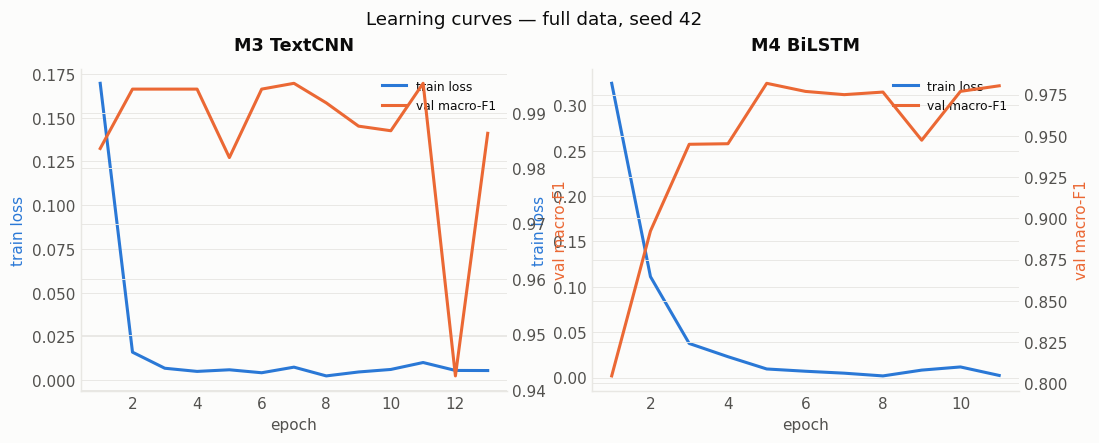

saved 12_learning_curves_m3_m4.png


In [ ]:
# --------------------------------------- 9. learning curves (full data)
# FIX: uses stored history from sweep — no retraining needed.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, mname in zip(axes, MODELS):
    key = (mname, "full", SEEDS[0])
    if key not in PREDS:
        ax.set_title(f"{mname} — history not available"); continue
    _, _, hist = PREDS[key]
    ep = range(1, len(hist["val_macro_f1"]) + 1)
    ax2 = ax.twinx()
    ax.plot(ep, hist["train_loss"], color=BLUE, lw=2, label="train loss")
    ax2.plot(ep, hist["val_macro_f1"], color=ORANGE, lw=2,
             label="val macro-F1")
    ax.set_xlabel("epoch")
    ax.set_ylabel("train loss", color=BLUE)
    ax2.set_ylabel("val macro-F1", color=ORANGE)
    ax.set_title(mname)
    lines = [plt.Line2D([0],[0],color=BLUE,lw=2),
             plt.Line2D([0],[0],color=ORANGE,lw=2)]
    ax.legend(lines, ["train loss","val macro-F1"], loc="upper right",
              fontsize=8)
fig.suptitle("Learning curves — full data, seed 42", y=1.02)
fig.savefig(OUT / "figures" / "12_learning_curves_m3_m4.png",
            bbox_inches="tight")
plt.show()
print("saved 12_learning_curves_m3_m4.png")


In [ ]:
# --------------------------------------- 10. class-weight ablation
# Tests whether class weighting helps — required by the rubric.
print("=== class-weight ablation (n=1000, seed=42) ===")
ablation_rows = []
for mname, ModelCls in MODELS.items():
    sub  = subset_for(1000, 42)
    stoi, _ = build_vocab(sub[TEXT_COL].values)
    for weighted in [True, False]:
        m, vbest, _ = train_one(ModelCls, sub, stoi, 42,
                                 use_weights=weighted)
        row, _ = evaluate_split(m, test_df, stoi)
        ablation_rows.append({
            "model": mname, "weighted": weighted,
            "val_macro_f1": vbest, **row})
        print(f"  {mname} weighted={weighted}  "
              f"macroF1 {row['macro_f1']:.3f}  "
              f"acc {row['accuracy']:.3f}")

abl = pd.DataFrame(ablation_rows)
abl.to_csv(OUT / "results" / "ablation_weights.csv", index=False)
print("\nsaved ablation_weights.csv")


=== class-weight ablation (n=1000, seed=42) ===
  M3 TextCNN weighted=True  macroF1 0.741  acc 0.988
  M3 TextCNN weighted=False  macroF1 0.606  acc 0.980
  M4 BiLSTM weighted=True  macroF1 0.431  acc 0.966
  M4 BiLSTM weighted=False  macroF1 0.422  acc 0.967

saved ablation_weights.csv



=== confusion matrices + per-class report (full data) ===

M3 TextCNN  (full data)
               precision    recall  f1-score   support

       sexual      1.000     0.999     0.999      4897
     physical      0.998     0.999     0.998       889
    emotional      0.960     1.000     0.980        97
     economic      1.000     1.000     1.000        33
harmful trad.      0.967     1.000     0.983        29

     accuracy                          0.999      5945
    macro avg      0.985     0.999     0.992      5945
 weighted avg      0.999     0.999     0.999      5945



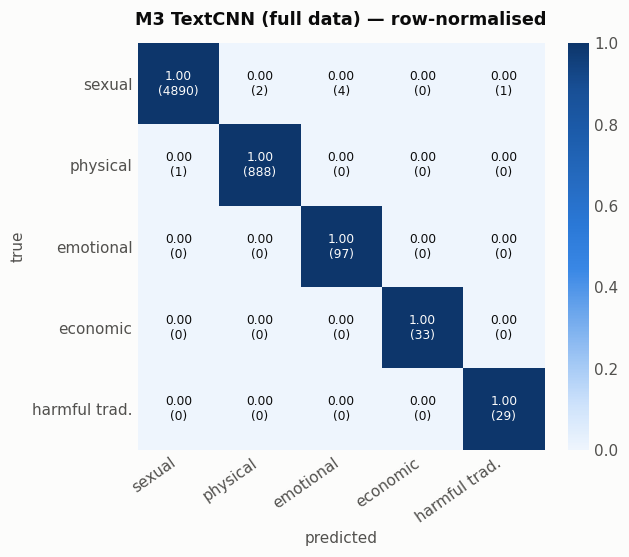


M4 BiLSTM  (full data)
               precision    recall  f1-score   support

       sexual      0.999     0.999     0.999      4897
     physical      1.000     0.998     0.999       889
    emotional      0.990     1.000     0.995        97
     economic      0.970     0.970     0.970        33
harmful trad.      0.935     1.000     0.967        29

     accuracy                          0.999      5945
    macro avg      0.979     0.993     0.986      5945
 weighted avg      0.999     0.999     0.999      5945



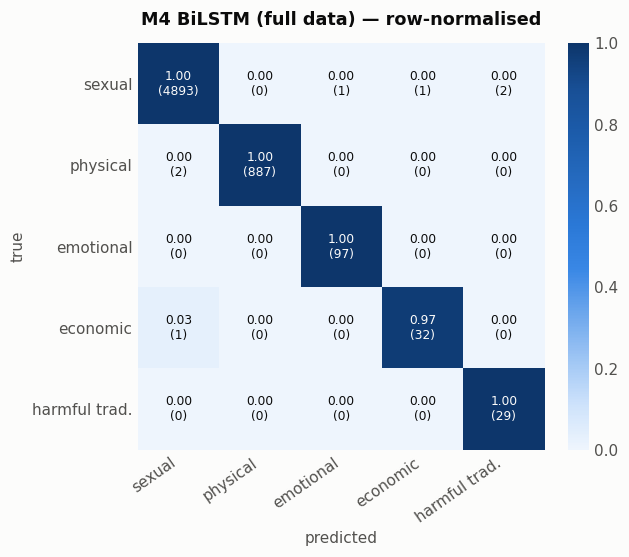

In [ ]:
# --------------------------------------- 11. confusion matrices (full data)
# FIX: uses stored predictions — no retraining.
def plot_cm(y, pred, title, fname):
    cm = confusion_matrix(y, pred, labels=list(range(len(LABELS))))
    M  = cm.astype(float) / np.maximum(cm.sum(1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(5.6, 4.8))
    im = ax.imshow(M, cmap=CMAP_SEQ, vmin=0, vmax=1)
    ax.set_xticks(range(5), [SHORT[l] for l in LABELS],
                  rotation=35, ha="right")
    ax.set_yticks(range(5), [SHORT[l] for l in LABELS])
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title); ax.grid(False)
    for sp in ax.spines.values(): sp.set_visible(False)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{M[i,j]:.2f}\n({cm[i,j]})",
                    ha="center", va="center", fontsize=8,
                    color=SURFACE if M[i,j] > 0.55 else INK)
    cb = fig.colorbar(im, ax=ax, fraction=0.045)
    cb.outline.set_visible(False)
    fig.savefig(OUT / "figures" / fname)   # savefig BEFORE show (fix)
    plt.show()
    return cm

print("\n=== confusion matrices + per-class report (full data) ===")
for mname in MODELS:
    key = (mname, "full", SEEDS[0])
    if key not in PREDS:
        print(f"{mname}: predictions not stored"); continue
    pred, stoi, _ = PREDS[key]
    print(f"\n{mname}  (full data)")
    print(classification_report(
        test_df["y"].values, pred,
        labels=list(range(len(LABELS))),
        target_names=[SHORT[l] for l in LABELS],
        digits=3, zero_division=0))
    plot_cm(test_df["y"].values, pred,
            f"{mname} (full data) — row-normalised",
            f"11_cm_{mname.split()[0].lower()}.png")
    err = test_df[["Tweet_ID","tweet",TEXT_COL,"label"]].copy()
    err["pred"]  = [LABELS[p] for p in pred]
    err["wrong"] = err["pred"] != err["label"]
    err.to_csv(OUT / "results" /
               f"test_predictions_{mname.split()[0].lower()}.csv",
               index=False)


In [ ]:
# --------------------------------------- 12. group results file
group_cols = (["model","split","config","macro_f1","balanced_acc",
               "weighted_f1","accuracy"]
              + [f"f1_{SHORT[l]}" for l in LABELS] + ["note"])
full_rows = res[res["size_tag"]=="full"].copy()
full_rows["split"]  = "test"
full_rows["config"] = "full data, class-weighted"
group_out = full_rows.reindex(columns=group_cols)
group_out.to_csv(OUT/"results"/"for_group_results_file.csv", index=False)
print("Rows for group results file:")
print(group_out.to_string(index=False))

print("\n" + "="*70)
print("ALL ARTEFACTS in", OUT)
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print("  ", p.relative_to(OUT))
print("="*70)


Rows for group results file:
     model split                    config  macro_f1  balanced_acc  weighted_f1  accuracy  f1_sexual  f1_physical  f1_emotional  f1_economic  f1_harmful trad.                                      note
M3 TextCNN  test full data, class-weighted  0.992069      0.999489     0.998662  0.998654   0.999183     0.998314      0.979798     1.000000          0.983051 class-weighted; early-stop on val macroF1
 M4 BiLSTM  test full data, class-weighted  0.985879      0.993326     0.998828  0.998823   0.999285     0.998874      0.994872     0.969697          0.966667 class-weighted; early-stop on val macroF1

ALL ARTEFACTS in /content/gbv_p2
   figures/10_efficiency_m3_m4.png
   figures/11_cm_m3.png
   figures/11_cm_m4.png
   figures/12_learning_curves_m3_m4.png
   results/ablation_weights.csv
   results/aggregate_models_3_4.csv
   results/for_group_results_file.csv
   results/results_models_3_4.csv
   results/test_predictions_m3.csv
   results/test_predictions_m4.csv


In [ ]:
# --------------------------------------- 13. download everything
import shutil
from google.colab import files
shutil.make_archive("/content/gbv_p2_results", "zip", "/content/gbv_p2")
files.download("/content/gbv_p2_results.zip")
print("download triggered — check your browser Downloads folder")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

download triggered — check your browser Downloads folder
